# 🛒 Olist E-Commerce — Product & Category Analysis

> **Author:** Mauricio Mendizábal <br>
> **Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
> **Goal:** Identify which product categories drive the most sales, and whether high-volume categories also deliver high customer satisfaction.

---

## Contents
1. [Setup & Database Loading](#1-setup--database-loading)
2. [Data Quality Audit](#2-data-quality-audit)
3. [Top Categories by Volume](#3-top-categories-by-volume)
4. [Revenue by Category](#4-revenue-by-category)
5. [Customer Satisfaction by Category](#5-customer-satisfaction-by-category)
6. [Volume vs Satisfaction: The Key Tension](#6-volume-vs-satisfaction-the-key-tension)
7. [Delivery Time & Its Effect on Reviews](#7-delivery-time--its-effect-on-reviews)
8. [Conclusions](#8-conclusions)


---
## 1. Setup & Database Loading

We load the CSV files into a local SQLite database. This simulates the real-world workflow where data lives in a relational database and is queried with SQL before further analysis in Python.

In [15]:
import warnings
warnings.filterwarnings('ignore')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── visual theme ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

ACCENT  = '#E63946'
BLUE    = '#457B9D'
TEAL    = '#2A9D8F'
YELLOW  = '#E9C46A'
PALETTE = [BLUE, TEAL, ACCENT, YELLOW, '#264653']

In [16]:
# ── Load CSVs ─────────────────────────────────────────────────────────
DATA_PATH = r'C:\Users\Usuario\Desktop\Análisis de Datos\Cuarto Proyecto\data\\'

orders       = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items  = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products     = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
customers    = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
reviews      = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
payments     = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
category_translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print('Loaded tables:')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('products', products), ('customers', customers),
                 ('reviews', reviews), ('payments', payments), ('category_translation', category_translation)]:
    print(f'  {name:<25s}: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded tables:
  orders                   : 99,441 rows × 8 columns
  order_items              : 112,650 rows × 7 columns
  products                 : 32,951 rows × 9 columns
  customers                : 99,441 rows × 5 columns
  reviews                  : 99,224 rows × 7 columns
  payments                 : 103,886 rows × 5 columns
  category_translation     : 71 rows × 2 columns


In [17]:
# ── Load into SQLite ──────────────────────────────────────────────────
conn = sqlite3.connect(':memory:')  # in-memory database

orders.to_sql('orders', conn, if_exists='replace', index=False)
order_items.to_sql('order_items', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
customers.to_sql('customers', conn, if_exists='replace', index=False)
reviews.to_sql('reviews', conn, if_exists='replace', index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
category_translation.to_sql('category_translation', conn, if_exists='replace', index=False)

print('All tables loaded into SQLite.')
print('Tables available:', pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist())

All tables loaded into SQLite.
Tables available: ['orders', 'order_items', 'products', 'customers', 'reviews', 'payments', 'category_translation']


---
## 2. Data Quality Audit

Before any analysis, we check for missing values and understand the scope of the dataset.

In [18]:
# ── Overview query ────────────────────────────────────────────────────
overview = pd.read_sql_query("""
    SELECT
        COUNT(DISTINCT o.order_id)              AS total_orders,
        COUNT(DISTINCT o.customer_id)           AS total_customers,
        COUNT(DISTINCT oi.product_id)           AS total_products,
        COUNT(DISTINCT p.product_category_name) AS total_categories
    FROM orders o
    LEFT JOIN order_items oi ON o.order_id = oi.order_id
    LEFT JOIN products p ON oi.product_id = p.product_id
    WHERE o.order_status = 'delivered'
""", conn)

print('Dataset scope (delivered orders only):')
print(overview.to_string(index=False))

Dataset scope (delivered orders only):
 total_orders  total_customers  total_products  total_categories
        96478            96478           32216                73


In [19]:
# ── Missing category names ────────────────────────────────────────────
missing_categories = pd.read_sql_query("""
    SELECT
        COUNT(*) AS total_products,
        SUM(CASE WHEN product_category_name IS NULL THEN 1 ELSE 0 END) AS missing_category,
        ROUND(100.0 * SUM(CASE WHEN product_category_name IS NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_missing
    FROM products
""", conn)

print('Missing category names in products table:')
print(missing_categories.to_string(index=False))
print('\nDecision: exclude products with no category from category-level analysis.')

Missing category names in products table:
 total_products  missing_category  pct_missing
          32951               610          1.9

Decision: exclude products with no category from category-level analysis.


### Cleaning decisions

| Issue | Decision | Rationale |
|---|---|---|
| Orders not yet delivered | Filter to `order_status = 'delivered'` only | Non-delivered orders distort revenue and review analysis |
| Products with no category | Exclude from category analysis | ~2% of products — negligible |
| Category names in Portuguese | Join with `category_translation` table | More readable for international portfolio |
| Duplicate reviews per order | Keep first review per order | A small number of orders have multiple reviews |


---
## 3. Top Categories by Volume

We start with the most fundamental question: **which categories sell the most units?**

In [20]:
top_volume = pd.read_sql_query("""
    SELECT
        COALESCE(ct.product_category_name_english, p.product_category_name) AS category,
        COUNT(oi.order_item_id) AS units_sold,
        COUNT(DISTINCT oi.order_id) AS total_orders
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    WHERE o.order_status = 'delivered'
      AND p.product_category_name IS NOT NULL
    GROUP BY category
    ORDER BY units_sold DESC
    LIMIT 15
""", conn)

print(top_volume.to_string(index=False))

             category  units_sold  total_orders
       bed_bath_table       10953          9272
        health_beauty        9465          8647
       sports_leisure        8431          7530
      furniture_decor        8160          6307
computers_accessories        7644          6530
           housewares        6795          5743
        watches_gifts        5859          5495
            telephony        4430          4093
         garden_tools        4268          3448
                 auto        4140          3810
                 toys        4030          3804
           cool_stuff        3718          3559
            perfumery        3340          3086
                 baby        2982          2809
          electronics        2729          2517


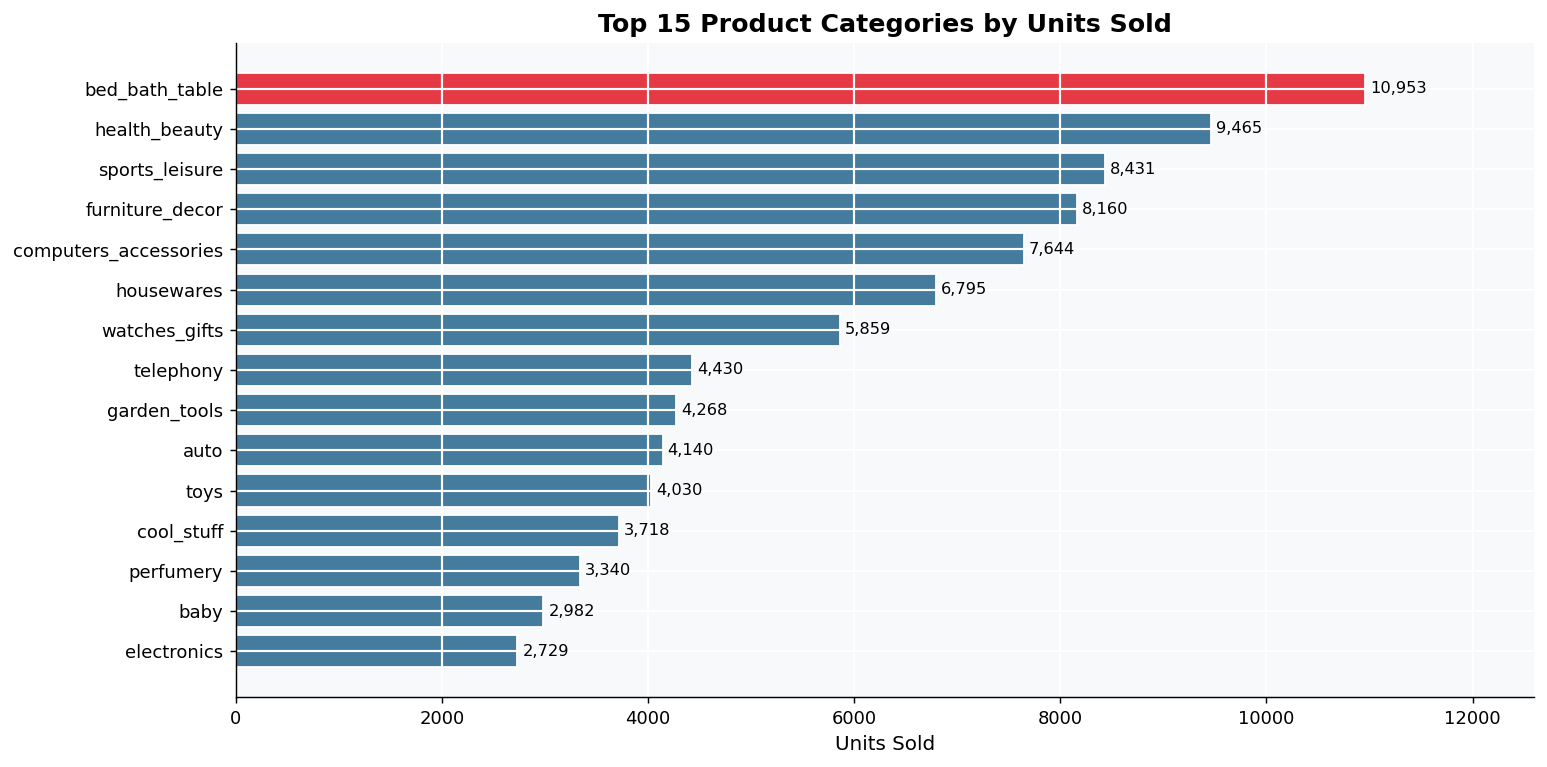

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = [ACCENT if i == 0 else BLUE for i in range(len(top_volume))]
bars = ax.barh(
    top_volume['category'][::-1],
    top_volume['units_sold'][::-1],
    color=colors[::-1], edgecolor='white'
)
for bar, val in zip(bars, top_volume['units_sold'][::-1]):
    ax.text(
        bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', fontsize=9
    )
ax.set_title('Top 15 Product Categories by Units Sold')
ax.set_xlabel('Units Sold')
ax.set_xlim(0, top_volume['units_sold'].max() * 1.15)
plt.tight_layout()
plt.show()

---
## 4. Revenue by Category

Volume alone is misleading — a category can sell many cheap items while generating less revenue than one that sells fewer but more expensive products.

In [22]:
revenue_by_category = pd.read_sql_query("""
    SELECT
        COALESCE(ct.product_category_name_english, p.product_category_name) AS category,
        COUNT(oi.order_item_id)             AS units_sold,
        ROUND(SUM(oi.price), 2)             AS total_revenue,
        ROUND(AVG(oi.price), 2)             AS avg_price
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    WHERE o.order_status = 'delivered'
      AND p.product_category_name IS NOT NULL
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 15
""", conn)

print(revenue_by_category.to_string(index=False))

             category  units_sold  total_revenue  avg_price
        health_beauty        9465     1233131.72     130.28
        watches_gifts        5859     1166176.98     199.04
       bed_bath_table       10953     1023434.76      93.44
       sports_leisure        8431      954852.55     113.25
computers_accessories        7644      888724.61     116.26
      furniture_decor        8160      711927.69      87.25
           housewares        6795      615628.69      90.60
           cool_stuff        3718      610204.10     164.12
                 auto        4140      578966.65     139.85
                 toys        4030      471286.48     116.94
         garden_tools        4268      470495.28     110.24
                 baby        2982      400421.84     134.28
            perfumery        3340      390144.65     116.81
            telephony        4430      309860.23      69.95
     office_furniture        1668      268154.31     160.76


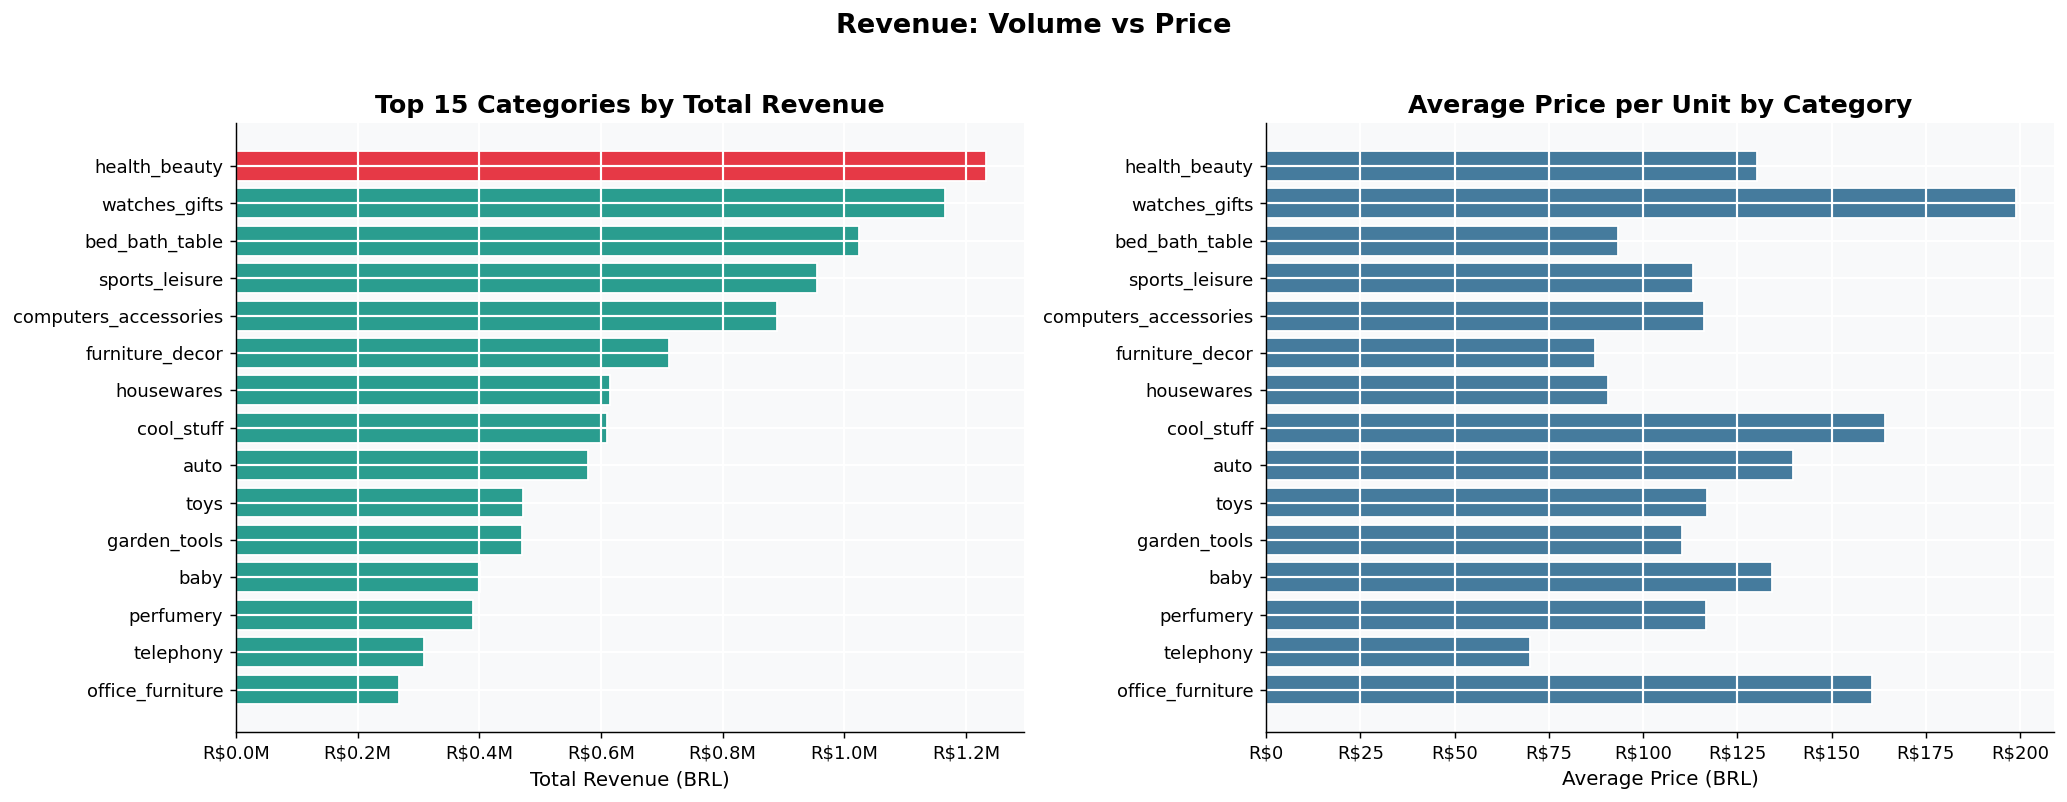

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: total revenue ───────────────────────────────────────────────
colors_rev = [ACCENT if i == 0 else TEAL for i in range(len(revenue_by_category))]
axes[0].barh(
    revenue_by_category['category'][::-1],
    revenue_by_category['total_revenue'][::-1],
    color=colors_rev[::-1], edgecolor='white'
)
axes[0].set_title('Top 15 Categories by Total Revenue')
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

# ── Right: average price ──────────────────────────────────────────────
axes[1].barh(
    revenue_by_category['category'][::-1],
    revenue_by_category['avg_price'][::-1],
    color=BLUE, edgecolor='white'
)
axes[1].set_title('Average Price per Unit by Category')
axes[1].set_xlabel('Average Price (BRL)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))

plt.suptitle('Revenue: Volume vs Price', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Customer Satisfaction by Category

Review scores (1–5) tell us whether customers are actually happy with what they buy. A category that sells a lot but generates poor reviews is a business risk.

In [24]:
satisfaction = pd.read_sql_query("""
    WITH first_review AS (
        SELECT order_id, review_score
        FROM reviews
        WHERE review_score IS NOT NULL
        GROUP BY order_id
    )
    SELECT
        COALESCE(ct.product_category_name_english, p.product_category_name) AS category,
        COUNT(oi.order_item_id)             AS units_sold,
        ROUND(AVG(r.review_score), 2)       AS avg_review_score,
        COUNT(r.review_score)               AS reviews_count
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    LEFT JOIN first_review r ON oi.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND p.product_category_name IS NOT NULL
    GROUP BY category
    HAVING reviews_count >= 50
    ORDER BY avg_review_score DESC
""", conn)

print('Best reviewed categories (min. 50 reviews):')
print(satisfaction.head(10).to_string(index=False))
print('\nWorst reviewed categories:')
print(satisfaction.tail(10).to_string(index=False))

Best reviewed categories (min. 50 reviews):
                             category  units_sold  avg_review_score  reviews_count
                       books_imported          57              4.51             57
               books_general_interest         537              4.51            533
small_appliances_home_oven_and_coffee          73              4.44             73
              costruction_tools_tools         103              4.44             99
                      books_technical         263              4.39            262
                           food_drink         269              4.36            269
                  luggage_accessories        1077              4.35           1073
                        fashion_shoes         257              4.30            253
                           cine_photo          70              4.29             70
                                 food         499              4.26            487

Worst reviewed categories:
               

---
## 6. Volume vs Satisfaction: The Key Tension

This is the most actionable analysis: **which high-volume categories have poor reviews?**

These are the categories where the business has the most to gain from improvement — they already have demand, but are losing customer loyalty.

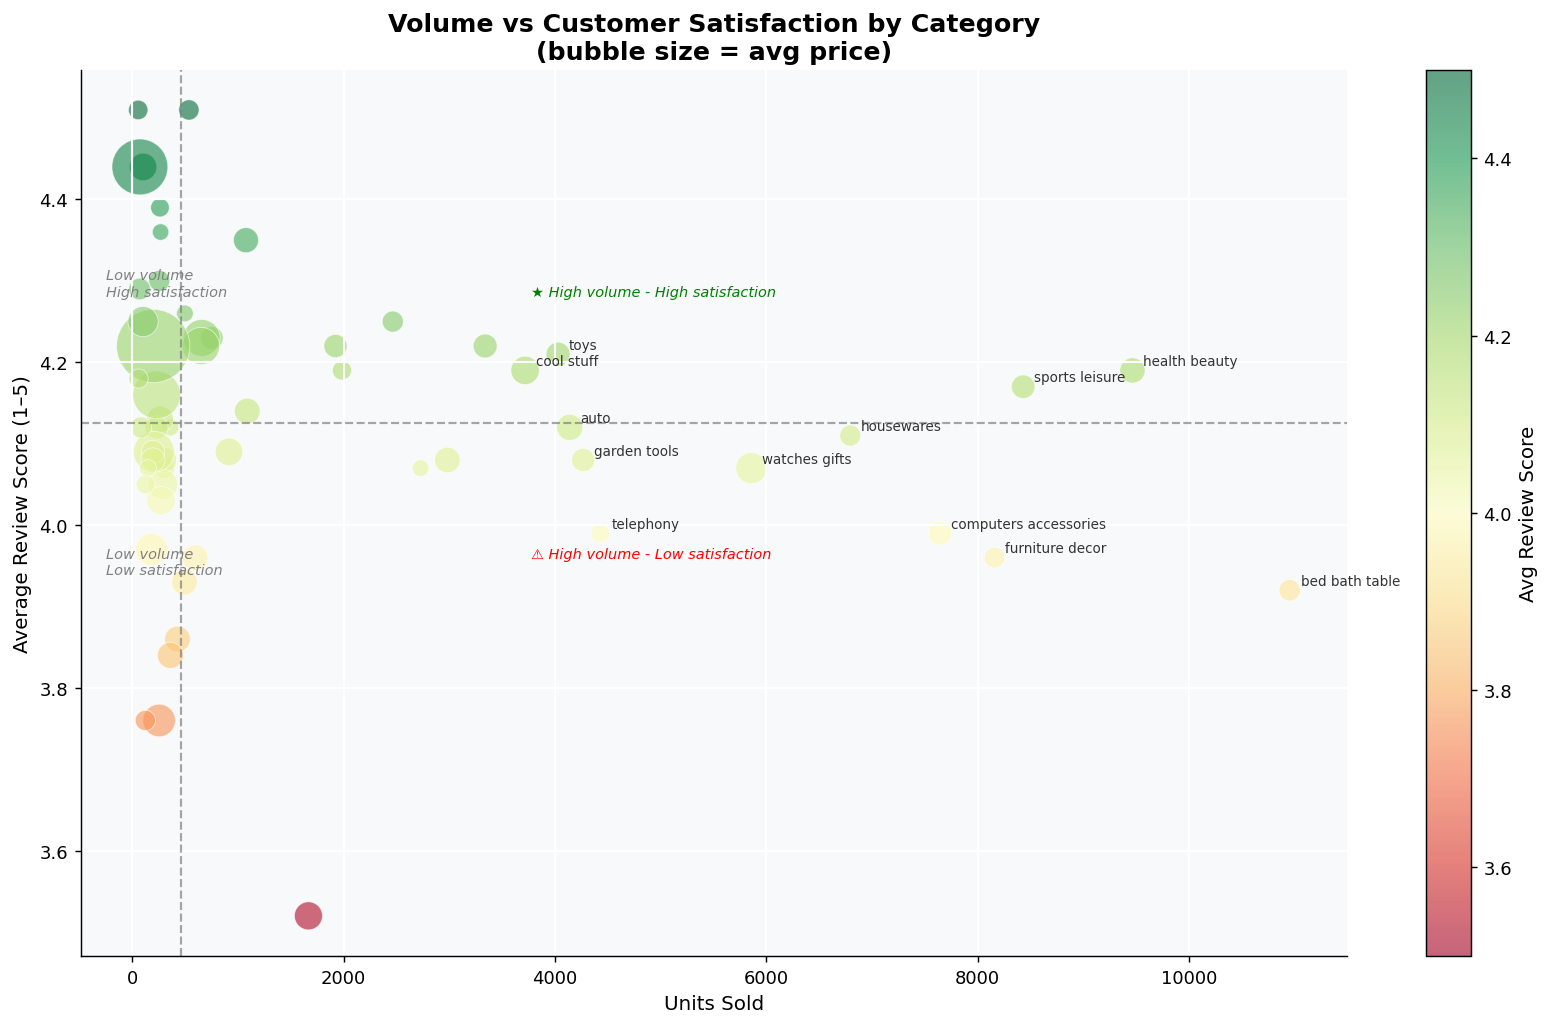

In [35]:
# Merge volume and satisfaction for all categories with enough reviews
volume_all = pd.read_sql_query("""
    WITH first_review AS (
        SELECT order_id, review_score
        FROM reviews
        WHERE review_score IS NOT NULL
        GROUP BY order_id
    )
    SELECT
        COALESCE(ct.product_category_name_english, p.product_category_name) AS category,
        COUNT(oi.order_item_id)             AS units_sold,
        ROUND(AVG(r.review_score), 2)       AS avg_review_score,
        ROUND(AVG(oi.price), 2)             AS avg_price
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    LEFT JOIN first_review r ON oi.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND p.product_category_name IS NOT NULL
    GROUP BY category
    HAVING COUNT(r.review_score) >= 50
    ORDER BY units_sold DESC
""", conn)

fig, ax = plt.subplots(figsize=(13, 8))

avg_score = volume_all['avg_review_score'].mean()
avg_volume = volume_all['units_sold'].median()

scatter = ax.scatter(
    volume_all['units_sold'],
    volume_all['avg_review_score'],
    s=volume_all['avg_price'] * 1.5,
    alpha=0.6,
    c=volume_all['avg_review_score'],
    cmap='RdYlGn',
    vmin=3.5, vmax=4.5,
    edgecolors='white', linewidth=0.5
)

# Quadrant lines
ax.axhline(avg_score, color='gray', linestyle='--', lw=1.2, alpha=0.7)
ax.axvline(avg_volume, color='gray', linestyle='--', lw=1.2, alpha=0.7)

# Quadrant labels
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

offset_x = (xmax - xmin) * 0.02
offset_y = (ymax - ymin) * 0.02

ax.text(xmin + offset_x, avg_score + offset_y*7, 
        'Low volume\nHigh satisfaction', 
        fontsize=8, color='gray', style='italic', va='bottom')

ax.text(avg_volume + (xmax - avg_volume) * 0.3, avg_score + offset_y*7, 
        '★ High volume - High satisfaction', 
        fontsize=8, color='green', style='italic', va='bottom')

ax.text(xmin + offset_x, avg_score - offset_y*7, 
        'Low volume\nLow satisfaction', 
        fontsize=8, color='gray', style='italic', va='top')

ax.text(avg_volume + (xmax - avg_volume) * 0.3, avg_score - offset_y*7, 
        '⚠ High volume - Low satisfaction', 
        fontsize=8, color='red', style='italic', va='top')

# Label top categories
top_categories = volume_all.nlargest(12, 'units_sold')
for _, row in top_categories.iterrows():
    ax.annotate(
        row['category'].replace('_', ' '),
        (row['units_sold'], row['avg_review_score']),
        textcoords='offset points', xytext=(6, 3),
        fontsize=7.5, color='#333333'
    )

plt.colorbar(scatter, ax=ax, label='Avg Review Score')
ax.set_title('Volume vs Customer Satisfaction by Category\n(bubble size = avg price)', fontsize=14, fontweight='bold')
ax.set_xlabel('Units Sold')
ax.set_ylabel('Average Review Score (1–5)')
plt.tight_layout()
plt.show()

---
## 7. Delivery Time & Its Effect on Reviews

A natural question: **are poor reviews driven by the product itself, or by slow delivery?**

If delivery time is the main driver, that's a logistics problem — not a product quality problem. The business implication is very different.

In [26]:
delivery = pd.read_sql_query("""
    WITH first_review AS (
        SELECT order_id, review_score
        FROM reviews
        WHERE review_score IS NOT NULL
        GROUP BY order_id
    ),
    delivery_times AS (
        SELECT
            order_id,
            ROUND(
                julianday(order_delivered_customer_date) -
                julianday(order_purchase_timestamp)
            ) AS delivery_days
        FROM orders
        WHERE order_status = 'delivered'
          AND order_delivered_customer_date IS NOT NULL
          AND order_purchase_timestamp IS NOT NULL
    )
    SELECT
        dt.delivery_days,
        r.review_score
    FROM delivery_times dt
    JOIN first_review r ON dt.order_id = r.order_id
    WHERE dt.delivery_days BETWEEN 1 AND 60
""", conn)

print(f'Orders analyzed: {len(delivery):,}')
print(f'Avg delivery time: {delivery["delivery_days"].mean():.1f} days')
print(f'Median delivery time: {delivery["delivery_days"].median():.0f} days')

Orders analyzed: 95,542
Avg delivery time: 12.3 days
Median delivery time: 10 days


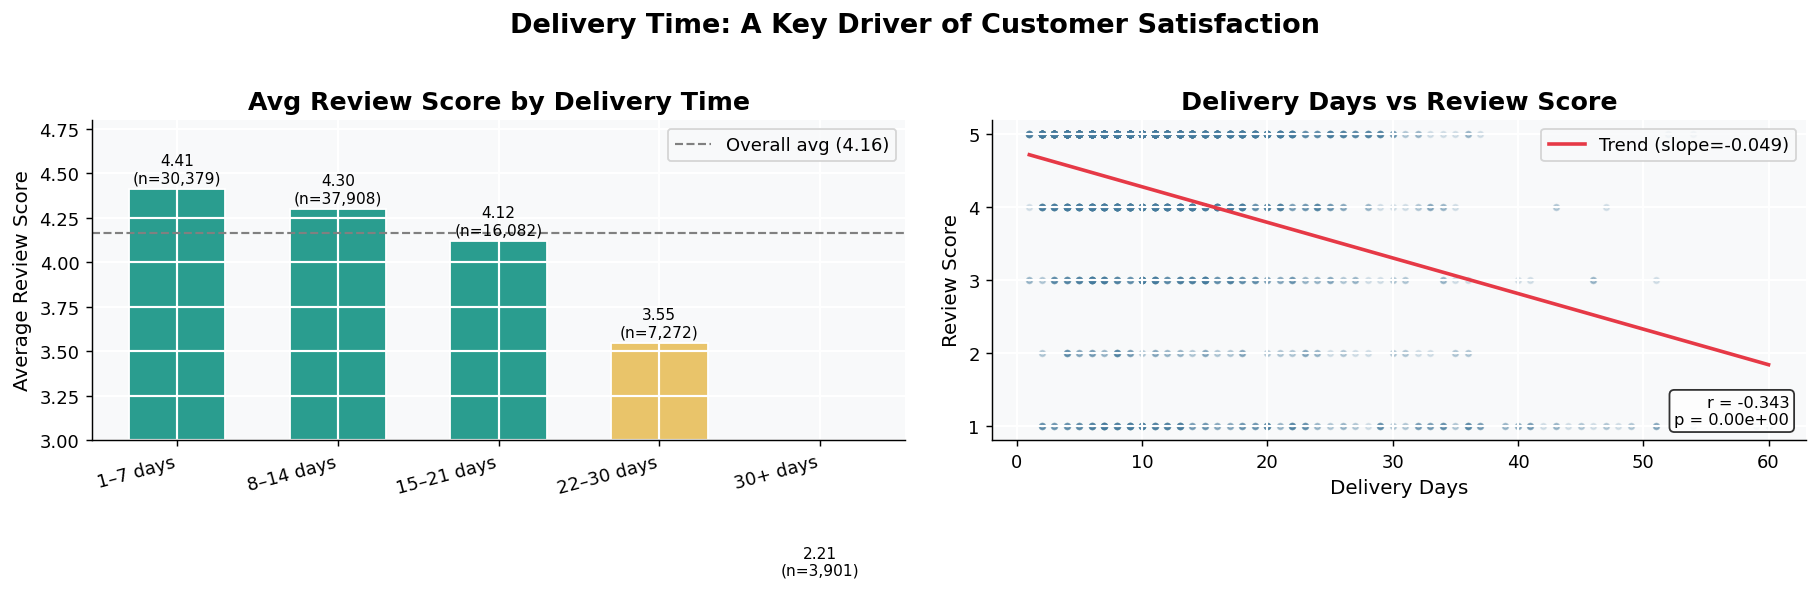


Pearson correlation (delivery days vs review score): r=-0.343, p=0.00e+00
→ Negative correlation: longer delivery = lower review score


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: avg review score by delivery time band ──────────────────────
delivery['delivery_band'] = pd.cut(
    delivery['delivery_days'],
    bins=[0, 7, 14, 21, 30, 60],
    labels=['1–7 days', '8–14 days', '15–21 days', '22–30 days', '30+ days']
)
band_scores = delivery.groupby('delivery_band', observed=True)['review_score'].agg(['mean', 'count'])

colors_delivery = ['#2A9D8F' if s >= 4.0 else '#E9C46A' if s >= 3.5 else '#E63946'
                   for s in band_scores['mean']]
bars = axes[0].bar(
    range(len(band_scores)),
    band_scores['mean'],
    color=colors_delivery, edgecolor='white', width=0.6
)
for i, (bar, (score, count)) in enumerate(zip(bars, band_scores.values)):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{score:.2f}\n(n={int(count):,})',
        ha='center', va='bottom', fontsize=8.5
    )
axes[0].set_xticks(range(len(band_scores)))
axes[0].set_xticklabels(band_scores.index, rotation=15, ha='right')
axes[0].set_title('Avg Review Score by Delivery Time')
axes[0].set_ylabel('Average Review Score')
axes[0].set_ylim(3.0, 4.8)
axes[0].axhline(delivery['review_score'].mean(), color='gray', linestyle='--', lw=1.2,
                label=f'Overall avg ({delivery["review_score"].mean():.2f})')
axes[0].legend()

# ── Right: scatter with trend line ───────────────────────────────────
sample = delivery.sample(min(3000, len(delivery)), random_state=42)
axes[1].scatter(
    sample['delivery_days'], sample['review_score'],
    alpha=0.15, color=BLUE, s=10
)
# trend line
z = np.polyfit(sample['delivery_days'], sample['review_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(1, 60, 100)
axes[1].plot(x_line, p(x_line), color=ACCENT, lw=2, label=f'Trend (slope={z[0]:.3f})')
axes[1].set_title('Delivery Days vs Review Score')
axes[1].set_xlabel('Delivery Days')
axes[1].set_ylabel('Review Score')
axes[1].legend()

# Correlation
corr, p_val = stats.pearsonr(delivery['delivery_days'], delivery['review_score'])
axes[1].text(0.98, 0.05, f'r = {corr:.3f}\np = {p_val:.2e}',
             transform=axes[1].transAxes, ha='right', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Delivery Time: A Key Driver of Customer Satisfaction', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nPearson correlation (delivery days vs review score): r={corr:.3f}, p={p_val:.2e}')
print('→ Negative correlation: longer delivery = lower review score')

---
## 8. Conclusions

### What the data tells us

**On volume:**
The top categories by units sold are dominated by everyday goods — bed & bath, health & beauty, sports & leisure. These are high-frequency, lower-ticket purchases.

**On revenue vs volume:**
Some categories rank lower in volume but higher in revenue due to higher average prices (e.g., computers, furniture). A business optimizing for revenue should treat these differently from a business optimizing for transaction volume.

**On the volume–satisfaction tension:**
The most actionable finding comes from the scatter plot in Section 6. Categories in the *high volume, low satisfaction* quadrant represent the greatest opportunity — they already have proven demand, but are underdelivering on customer experience. Improving quality or logistics in these categories would have outsized impact.

**On delivery time:**
There is a statistically significant negative correlation between delivery time and review score. Orders delivered in 1–7 days average well above 4 stars; orders taking 30+ days drop below 3.5. This suggests that **a significant portion of poor reviews are a logistics problem, not a product quality problem** — a critical distinction for business decision-making.

### Limitations

- The dataset covers 2016–2018. Consumer behavior and logistics infrastructure may have changed significantly since then.
- Review scores have a known bias toward extremes (1s and 5s) — average scores may mask bimodal distributions.
- We cannot distinguish whether poor reviews are caused by slow delivery or whether customers who receive slow deliveries are simply more likely to leave negative reviews regardless of product quality.
- The correlation between delivery time and review score, while statistically significant, is moderate (r ≈ −0.3). Many other factors drive satisfaction.

### What I Would Add With More Time

- Analyze review text (NLP) to separate complaints about delivery from complaints about product quality.
- Build a model to predict review score from delivery time, category, and price — to quantify each factor's independent contribution.
- Geographic analysis: which Brazilian states have the longest delivery times, and does that explain regional differences in satisfaction?

---
*This notebook was developed as a portfolio project combining SQL-based data extraction with Python visualization, simulating a real-world analytics workflow on a production e-commerce dataset.*